In [1]:
import matplotlib.pyplot as plt
import torch
import gymnasium as gym
import imageio
import dill
import numpy as np
import pandas as pd
from dataclasses import make_dataclass
import seaborn as sns

from four_room.env import FourRoomsEnv
from four_room.constants import train_config, size
from four_room.wrappers import gym_wrapper
gym.register('MiniGrid-FourRooms-v1', FourRoomsEnv)

%load_ext autoreload
%autoreload 2

In [ ]:
from copy import deepcopy

def plot_map(file_name: str, env_ids: int):
    env = gym_wrapper(gym.make(
            'MiniGrid-FourRooms-v1', 
            agent_pos= train_config['agent positions'],
            goal_pos = train_config['goal positions'],
            doors_pos = train_config['topologies'],
            agent_dir = train_config['agent directions'],
            size=size, 
            render_mode='rgb_array',
            disable_env_checker=True
        ),
        original_obs=True
    )        
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 20))
    
    with open(f'results/dqn_exps/{file_name}.pl', 'rb') as file:
        results = dill.load(file)

    for idx, ax in enumerate(axes.flat):
        matrix = results['heatmap'][env_ids[idx]]
        colors = np.full((19, 19), np.nan, dtype=float)

        colors[0, :] = 0
        colors[-1, :] = 0
        colors[:, 0] = 0
        colors[:, -1] = 0

        colors[9, :] = 0
        colors[:, 9] = 0
        
        env.get_wrapper_attr('set_context')(env_ids[idx])
        _, _ = env.reset()
        start_pos, doors_pos, goal_pos = env.get_wrapper_attr('context_info')(env_ids[idx])
        
        room_w = 19//2
        room_h = 19//2
        
        highlight_cells = []
        for j in range(0, 2):
            for i in range(0, 2):
                xL = i * room_w
                yT = j * room_h
                xR = xL + room_w
                yB = yT + room_h

                if i + 1 < 2:
                    pos = (xR, yT + 1 + doors_pos[j])
                    highlight_cells.append(pos)

                if j + 1 < 2:
                    pos = (xL + 1 + doors_pos[2 + i], yB)
                    highlight_cells.append(pos)
        
        colors[start_pos[0], start_pos[1]] = 1
        colors[goal_pos[0], goal_pos[1]] = 2

        for r, c in highlight_cells:
            colors[r, c] = np.nan

        matrix_data = deepcopy(matrix).astype(str)
        for r in range(matrix_data.shape[0]):
            for c in range(matrix_data.shape[1]):
                matrix_data[r, c] = str(int(matrix[r, c]))
                
        matrix_data[start_pos[0], start_pos[1]] = 'Start'
        matrix_data[goal_pos[0], goal_pos[1]] = 'Goal'
        
        sns.heatmap(matrix, cmap='magma', annot=matrix_data, cbar_kws={'label': 'Number of switches'}, ax=ax, fmt='')

        overlay_cmap = sns.color_palette(["grey", "red", "lime"])
        sns.heatmap(colors, cmap=overlay_cmap, mask=np.isnan(colors), cbar=False, alpha=0.6, ax=ax)
        ax.set_title(f"H0eatmap Env {env_ids[idx]}")

    plt.tight_layout()
    plt.show()

    env.close()

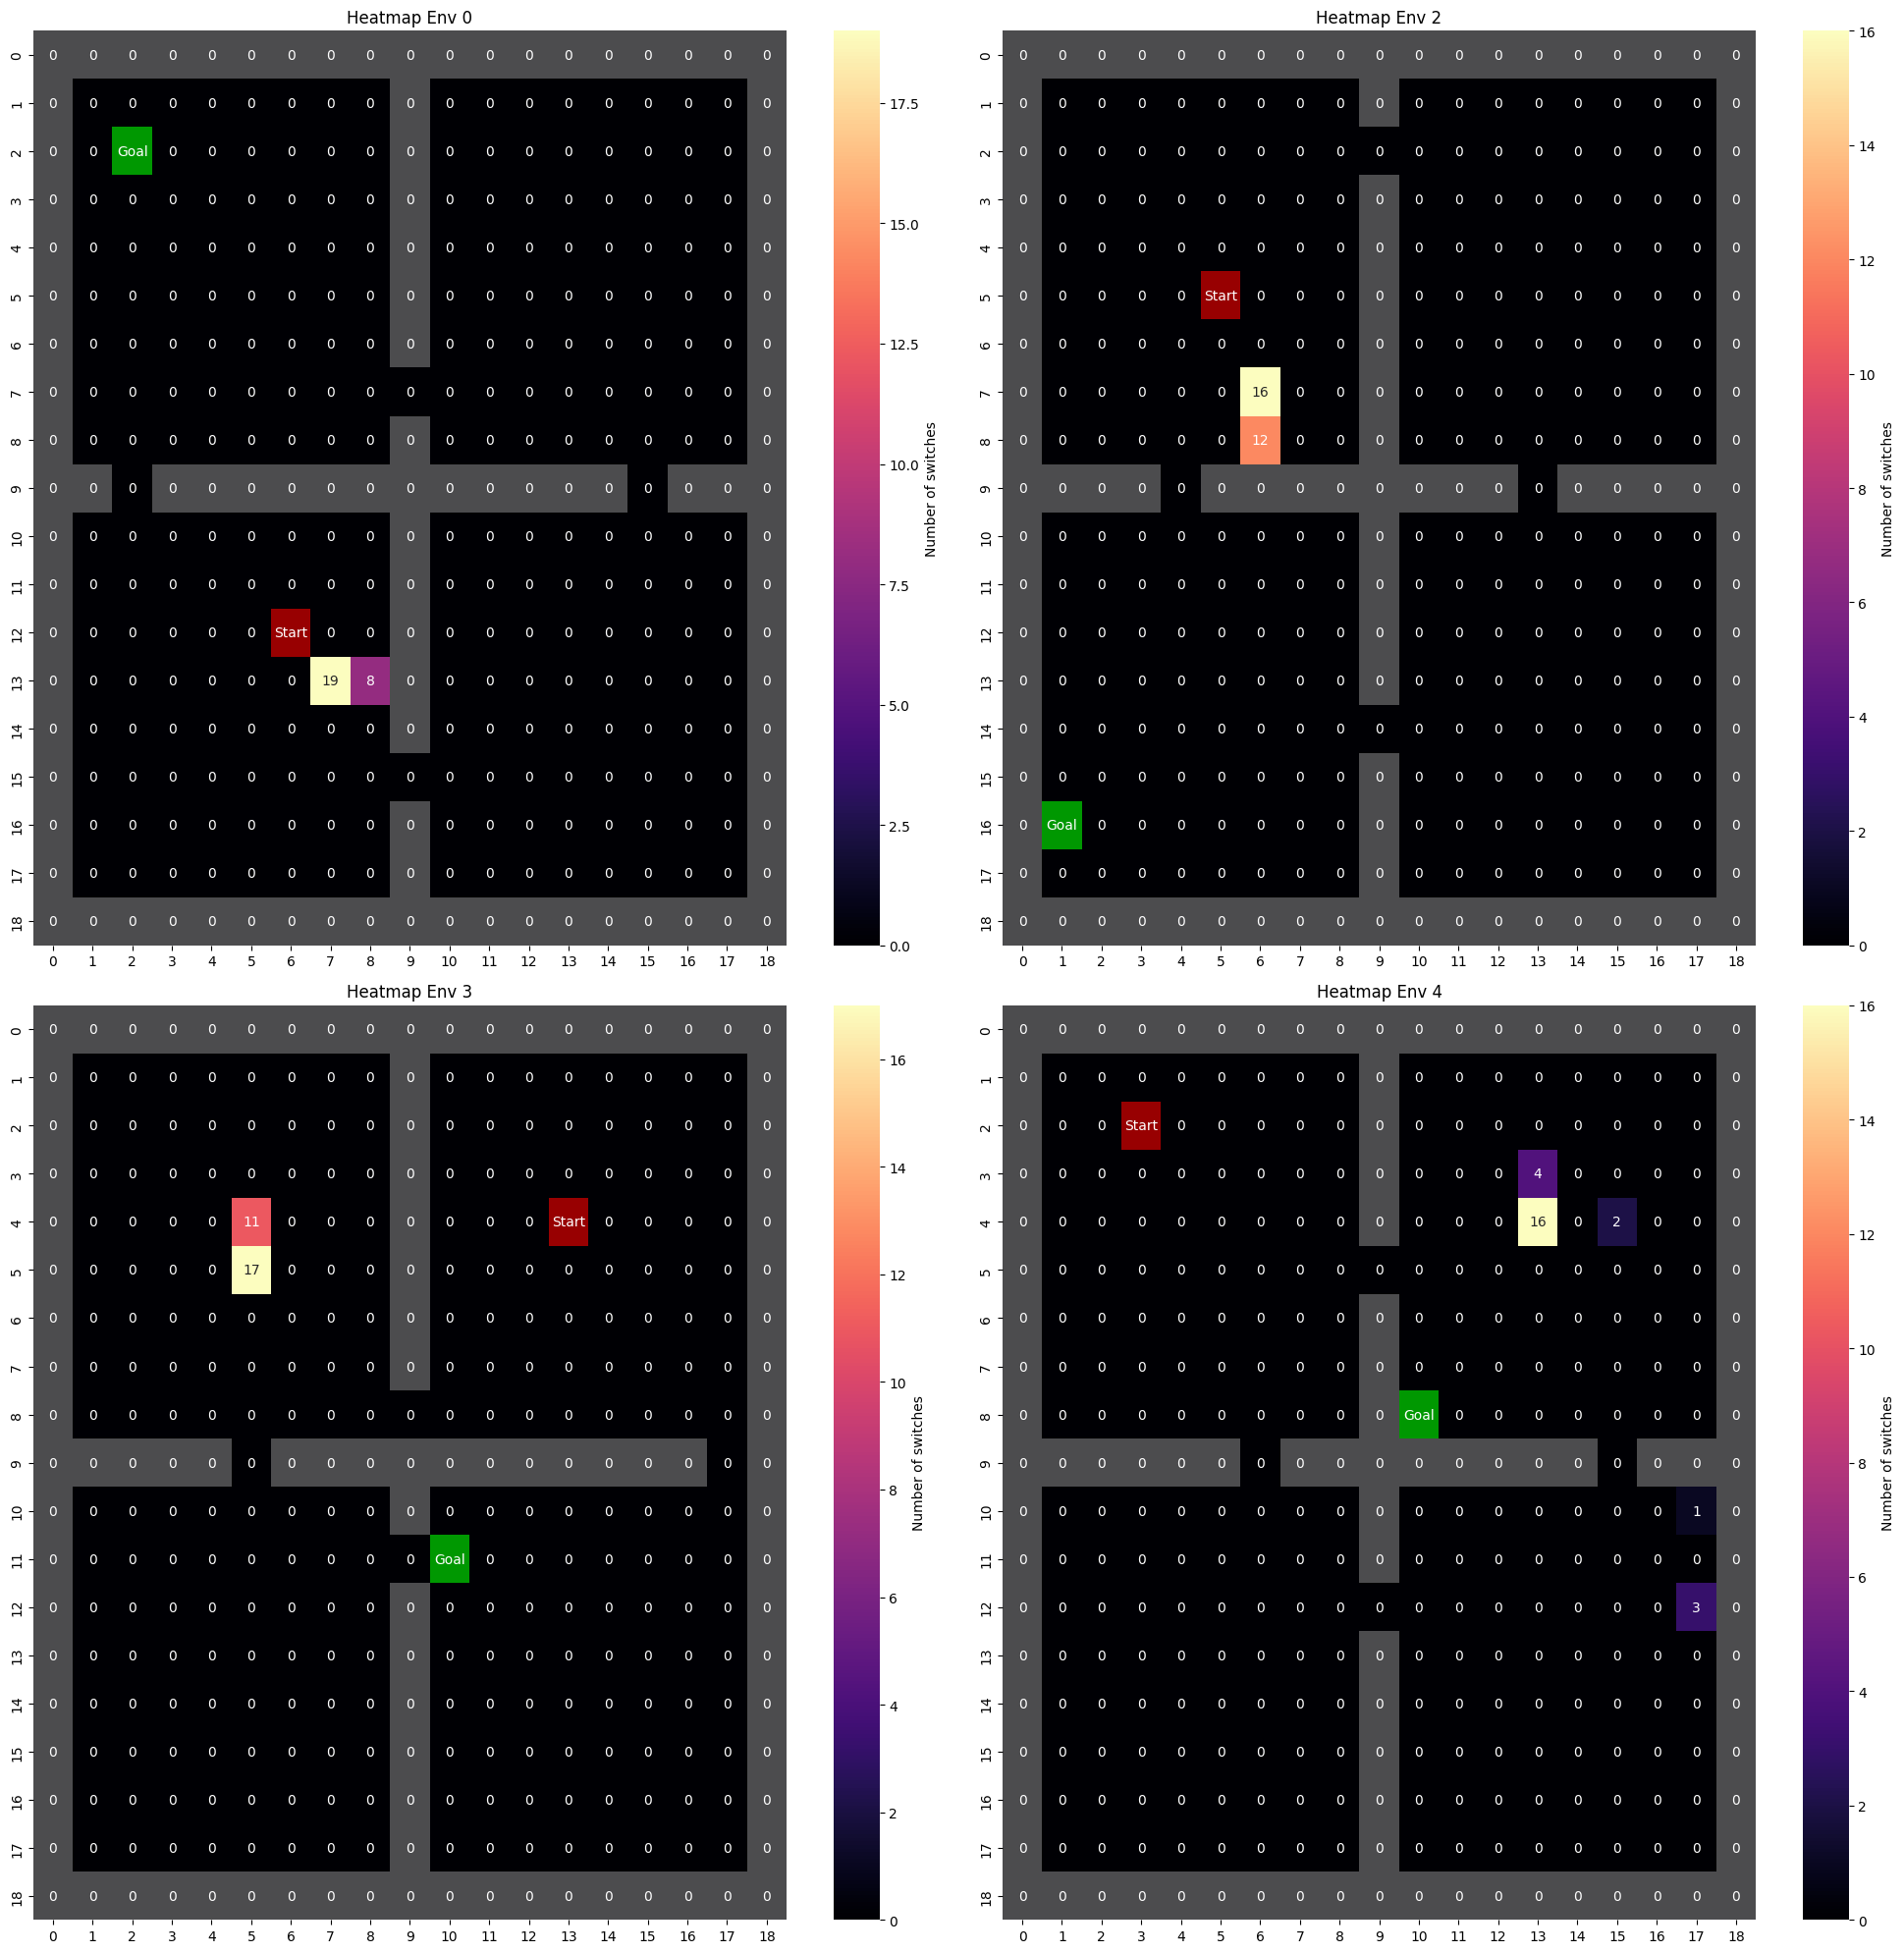

In [5]:
plot_map('basic_count_fixed_seed_0_100000', [0, 2, 3, 4])